In [1]:
# Basic
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# TensorFlow / Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import tensorflow as tf

# For prediction
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2



In [2]:
# Train generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (ONLY rescale)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train
train_data = train_datagen.flow_from_directory(
    "Dataset2/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Validation
val_data = val_test_datagen.flow_from_directory(
    "Dataset2/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Test
test_data = val_test_datagen.flow_from_directory(
    "Dataset2/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # important for evaluation
)

Found 2043 images belonging to 6 classes.
Found 439 images belonging to 6 classes.
Found 441 images belonging to 6 classes.


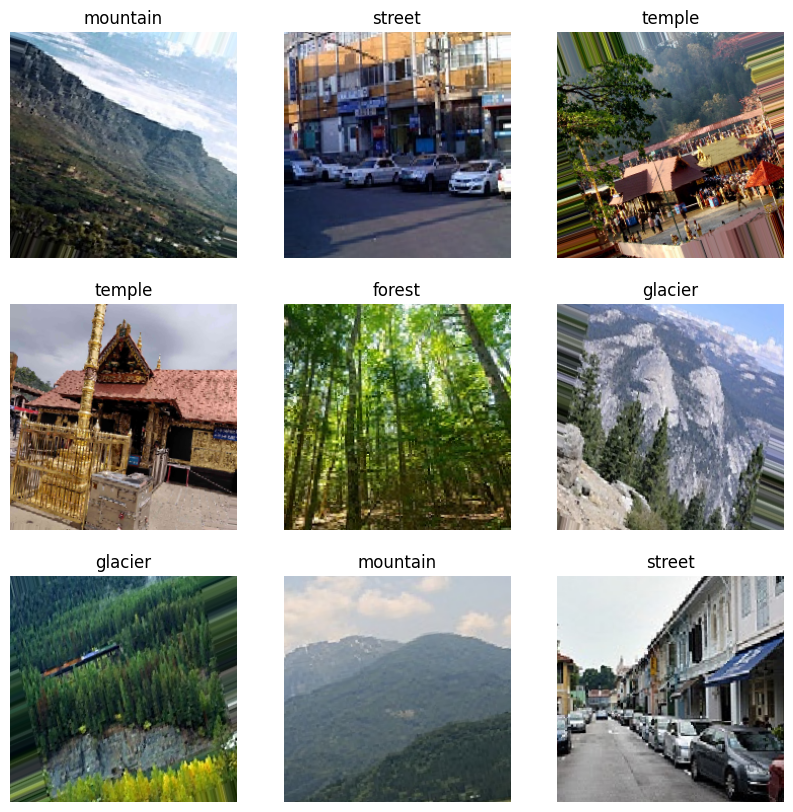

In [3]:
images, labels = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].argmax()])
    plt.axis('off')

plt.show()

In [4]:
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
# Train generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (ONLY rescale)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train
train_data = train_datagen.flow_from_directory(
    "Dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Validation
val_data = val_test_datagen.flow_from_directory(
    "Dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Test
test_data = val_test_datagen.flow_from_directory(
    "Dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # important for evaluation
)


model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=13
)

Found 420 images belonging to 6 classes.
Found 90 images belonging to 6 classes.
Found 90 images belonging to 6 classes.
Epoch 1/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 437ms/step - accuracy: 0.2048 - loss: 1.8012 - val_accuracy: 0.3778 - val_loss: 1.5287
Epoch 2/13
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 425ms/step - accuracy: 0.3429 - loss: 1.5469 - val_accuracy: 0.5667 - val_loss: 1.2036
Epoch 3/13


KeyboardInterrupt: 

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

NameError: name 'history' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


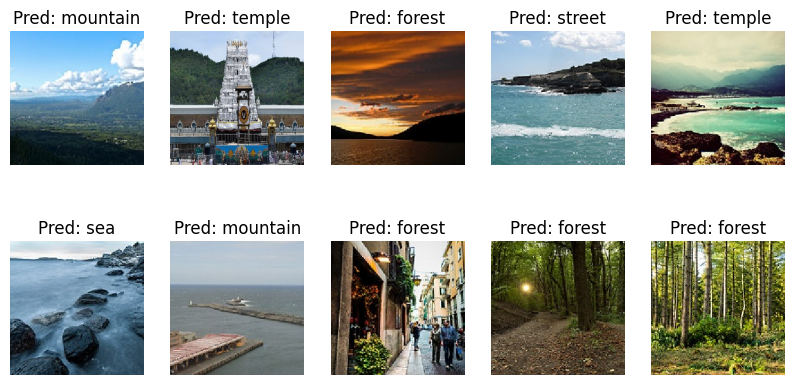

In [8]:
all_images = []

dataset_path = "Dataset2/test"

for category in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, category)
    if os.path.isdir(folder):
        for img in os.listdir(folder):
            all_images.append(os.path.join(folder, img))

# pick 3 random images
random_images = random.sample(all_images, 10)


class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10,5))

for i, img_path in enumerate(random_images):
    
    # load image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    pred = model.predict(img_array)
    predicted_class = class_names[np.argmax(pred)]

    # show image
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')

plt.show()

### Training using mobilenetv2

In [34]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "Intel-Image-Classification/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    "Intel-Image-Classification/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    "Intel-Image-Classification/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_data.num_classes

Found 12860 images belonging to 6 classes.
Found 1513 images belonging to 6 classes.
Found 3112 images belonging to 6 classes.


In [35]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [36]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [39]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=7,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/7
402/402 ━━━━━━━━━━━━━━━━━━━━ 79s 195ms/step - accuracy: 0.7757 - loss: 0.6682 - val_accuracy: 0.8976 - val_loss: 0.3153 - learning_rate: 1.0000e-04
Epoch 2/7
402/402 ━━━━━━━━━━━━━━━━━━━━ 108s 268ms/step - accuracy: 0.8348 - loss: 0.4754 - val_accuracy: 0.9187 - val_loss: 0.2665 - learning_rate: 1.0000e-04
Epoch 3/7
402/402 ━━━━━━━━━━━━━━━━━━━━ 128s 318ms/step - accuracy: 0.8586 - loss: 0.4126 - val_accuracy: 0.9207 - val_loss: 0.2558 - learning_rate: 1.0000e-04
Epoch 4/7
402/402 ━━━━━━━━━━━━━━━━━━━━ 122s 302ms/step - accuracy: 0.8668 - loss: 0.3885 - val_accuracy: 0.9273 - val_loss: 0.2414 - learning_rate: 1.0000e-04
Epoch 5/7
402/402 ━━━━━━━━━━━━━━━━━━━━ 120s 299ms/step - accuracy: 0.8767 - loss: 0.3579 - val_accuracy: 0.9286 - val_loss: 0.2270 - learning_rate: 1.0000e-04
Epoch 6/7
402/402 ━━━━━━━━━━━━━━━━━━━━ 129s 321ms/step - accuracy: 0.8780 - loss: 0.3346 - val_accuracy: 0.9253 - val_loss: 0.2269 - learning_rate: 1.0000e-04
Epoch 7/7
402/402 ━━━━━━━━━━━━━━━━━━━━ 133s 330

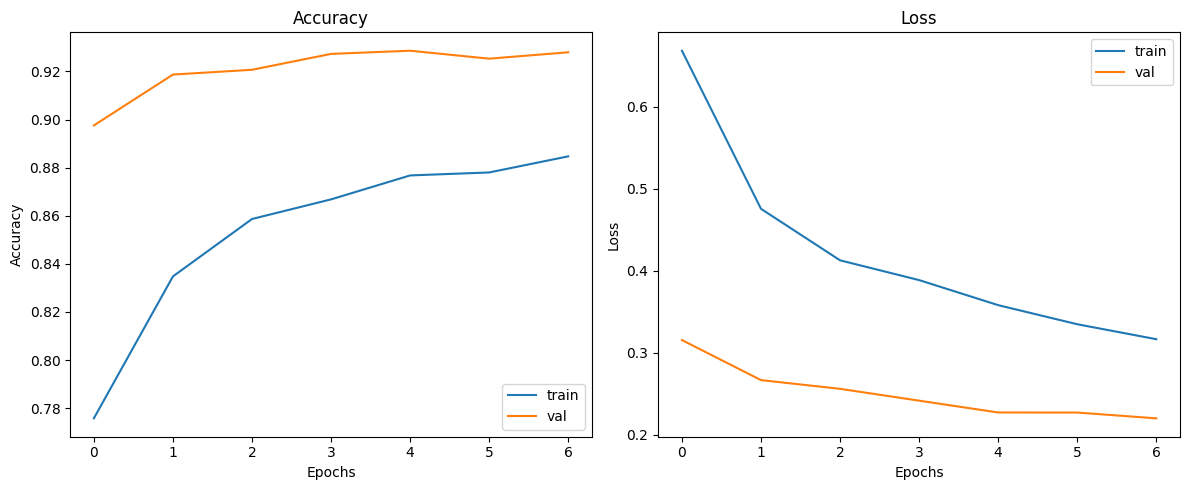

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['train','val'])

# Loss subplot
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['train','val'])

plt.tight_layout()
plt.show()

In [41]:
model.save("model_v2.h5")
print("Model saved successfully.")

Model saved successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


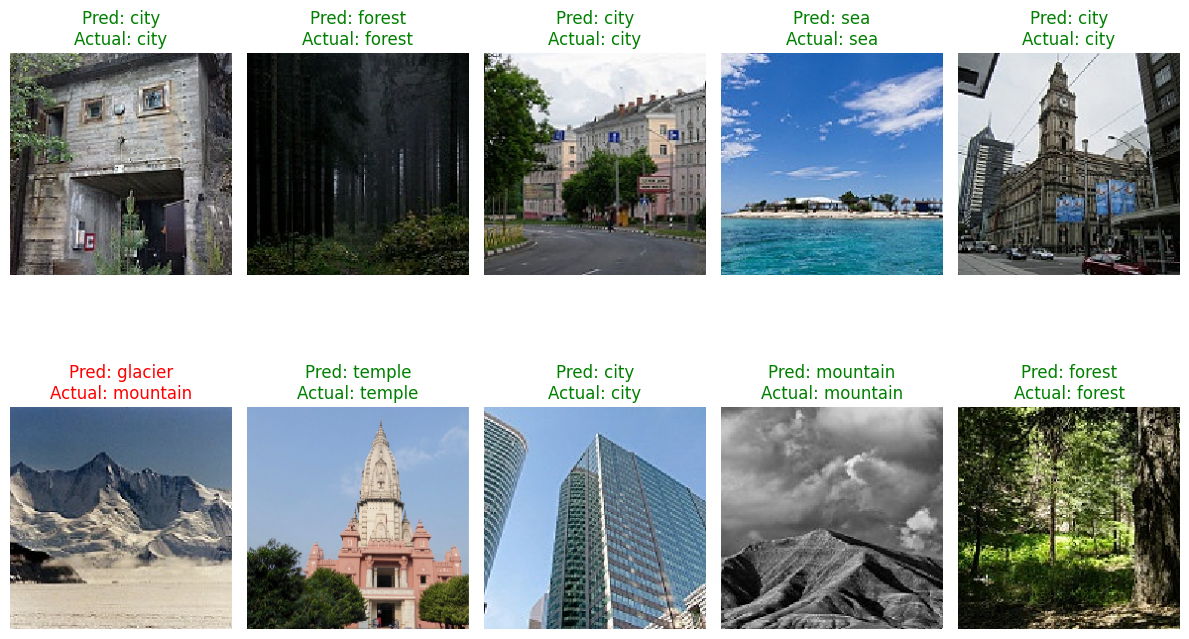

In [42]:
# get all data
images = []
labels = []

# collect multiple batches
for i in range(len(test_data)):
    x, y = test_data[i]
    images.extend(x)
    labels.extend(y)

images = np.array(images)
labels = np.array(labels)

# pick 10 random samples
indices = np.random.choice(len(images), 10, replace=False)

class_names = list(test_data.class_indices.keys())

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):
    
    img = images[idx]
    true_label = class_names[np.argmax(labels[idx])]
    
    pred = model.predict(np.expand_dims(img, axis=0))
    pred_label = class_names[np.argmax(pred)]
    
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    
    color = "green" if pred_label == true_label else "red"
    plt.title(f"Pred: {pred_label}\nActual: {true_label}", color=color)
    
    plt.axis('off')

plt.tight_layout()
plt.show()